In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),          # convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # normalize to [-1,1]
])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 592kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.05MB/s]


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolution layer: input 1 channel, output 32 filters, kernel 3x3
        self.conv1 = nn.Conv2d(1, 32, 3)
        # Max Pooling layer: 2x2 pooling
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layer: flatten 32*13*13 → 10 classes
        self.fc1 = nn.Linear(32*13*13, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # Conv → ReLU → Pool
        x = x.view(x.size(0), -1)                 # Flatten for FC layer
        x = self.fc1(x)                           # Output logits
        return x

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()  # for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
loss_list = []
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    loss_list.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1/5, Loss: 0.2128
Epoch 2/5, Loss: 0.0786
Epoch 3/5, Loss: 0.0601
Epoch 4/5, Loss: 0.0495
Epoch 5/5, Loss: 0.0431


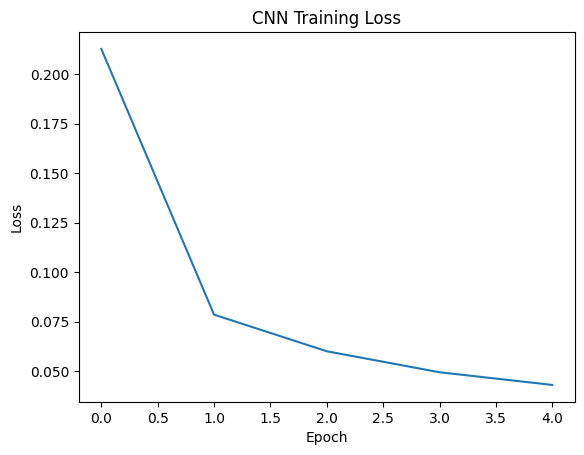

In [8]:
import matplotlib.pyplot as plt

plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.savefig("loss_cnn.png")
plt.show()

In [6]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.85%


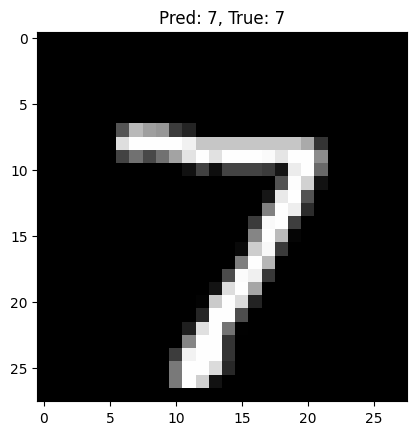

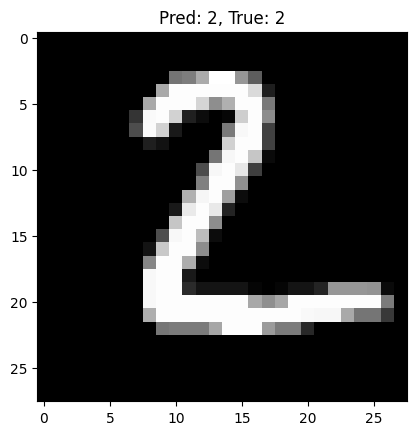

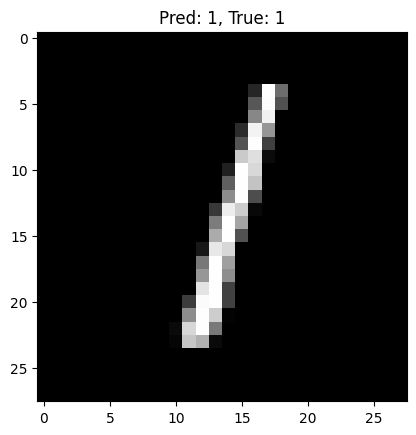

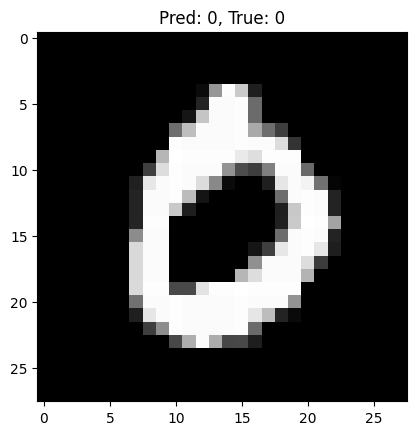

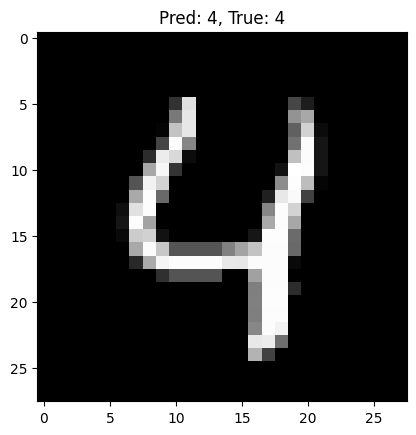

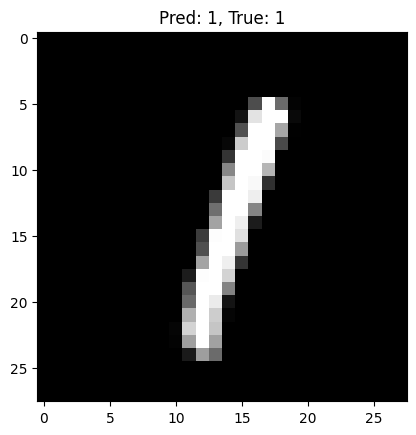

In [7]:
import matplotlib.pyplot as plt

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

# Plot first 6 images
for i in range(6):
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}, True: {labels[i].item()}")
    plt.show()

**Task 3 — Convolutional Neural Network (CNN)
Goal**
The goal of this task is to understand how Convolutional Neural Networks (CNNs) learn spatial features from images and compare their performance with Fully Connected Neural Networks (FCNN).

**Dataset**

We used the MNIST dataset, which contains:

60,000 training images

10,000 test images

Each image is 28×28 grayscale

Classes: digits (0–9)

**Model Architecture (CNN)**

The implemented CNN consists of:

**Convolution Layer**

nn.Conv2d(1, 32, 3)

Extracts spatial features like edges and patterns

**Pooling Layer**

nn.MaxPool2d(2, 2)

Reduces spatial size and computation

**Fully Connected Layer**

nn.Linear(32×13×13, 10)

Produces final classification output

**Training**

Optimizer: Adam

Loss Function: CrossEntropyLoss

Epochs: 5

Batch size: 64

**Results**

🔹 Accuracy Comparison


| Model | Accuracy |
| ----- | -------- |
| FCNN  | 85.55%   |
| CNN   | 97%      |


**Conclusion**

The CNN significantly outperforms the FCNN because:

CNN captures spatial relationships

Learns edges, shapes, and patterns

Reduces information loss compared to flattening